## Set up the input datasets

In [2]:
import pandas as pd

In [3]:
# Load the CSV file with labels
labels_df = pd.read_csv("/kaggle/input/bhf-data-science-centre-ecg-challenge/train_final.csv")

# Some images are broken/unreadable
# Use these lines to only read in the "valid" images to stop 
with open('/kaggle/input/bhf-reference-files/valid_images_list.txt', 'r') as file:
    valid_image_paths = [line.strip() for line in file]

with open('/kaggle/input/bhf-reference-files/valid_test_images_list.txt', 'r') as file:
    valid_test_images = [line.strip() for line in file]

## Defining segmentation model

In [4]:
import torchvision.transforms as T
import numpy as np
import cv2
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large, deeplabv3_resnet50
import torch
from PIL import Image

import sys

In [5]:
def generate_output(image: np.array, corners: list, scale: tuple = None, resize_shape: int = 640):
    corners = order_points(corners)

    if scale is not None:
        print(np.array(corners).shape, scale)
        corners = np.multiply(corners, scale)

    destination_corners = find_dest(corners)
    M = cv2.getPerspectiveTransform(np.float32(corners), np.float32(destination_corners))
    out = cv2.warpPerspective(image, M, (destination_corners[2][0], destination_corners[2][1]), flags=cv2.INTER_LANCZOS4)
    out = np.clip(out, a_min=0, a_max=255)
    out = out.astype(np.uint8)
    return out

def order_points(pts):
    """Rearrange coordinates to order:
    top-left, top-right, bottom-right, bottom-left"""
    rect = np.zeros((4, 2), dtype="float32")
    pts = np.array(pts)
    s = pts.sum(axis=1)
    # Top-left point will have the smallest sum.
    rect[0] = pts[np.argmin(s)]
    # Bottom-right point will have the largest sum.
    rect[2] = pts[np.argmax(s)]

    diff = np.diff(pts, axis=1)
    # Top-right point will have the smallest difference.
    rect[1] = pts[np.argmin(diff)]
    # Bottom-left will have the largest difference.
    rect[3] = pts[np.argmax(diff)]
    # return the ordered coordinates
    return rect.astype("int").tolist()

def find_dest(pts):
    (tl, tr, br, bl) = pts
    # Finding the maximum width.
    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))

    # Finding the maximum height.
    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxHeight = max(int(heightA), int(heightB))
    # Final destination co-ordinates.
    destination_corners = [[0, 0], [maxWidth, 0], [maxWidth, maxHeight], [0, maxHeight]]

    return order_points(destination_corners)

## Build a custom dataset class and dataloaders

In [6]:
import os
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt 

In [7]:
def image_preprocess_transforms(mean=(0.4611, 0.4359, 0.3905), std=(0.2193, 0.2150, 0.2109)):
    common_transforms = T.Compose([T.ToTensor(), T.Normalize(mean, std),])
    return common_transforms

def deep_learning_scan(og_image: np.array = None, 
                       trained_model=None, 
                       image_size=384, 
                       BUFFER=10, 
                       preprocess_transforms=image_preprocess_transforms(), 
                       device='cpu'):

    half = image_size // 2

    imH, imW, C = og_image.shape

    image_model = cv2.resize(og_image, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
    scale_x = imW / image_size
    scale_y = imH / image_size
    image_model = preprocess_transforms(image_model)
    image_model = torch.unsqueeze(image_model, dim=0)
    image_model = image_model.to('cpu')

    # # Device on CPU
    model_cpu = trained_model.to('cpu')
    model_cpu.eval()
    
    # Rest of your preprocessing remains the same, but use model_cpu
    with torch.no_grad():
        out = model_cpu(image_model)["out"]

    out = out.cpu()
    out = torch.argmax(out, dim=1, keepdims=True).permute(0, 2, 3, 1)[0].numpy().squeeze().astype(np.int32)

    r_H, r_W = out.shape

    _out_extended = np.zeros((image_size + r_H, image_size + r_W), dtype=out.dtype)
    _out_extended[half : half + image_size, half : half + image_size] = out * 255
    out = _out_extended.copy()

    # Edge Detection.
    canny = cv2.Canny(out.astype(np.uint8), 225, 255)
    canny = cv2.dilate(canny, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)))
    contours, _ = cv2.findContours(canny, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    page = sorted(contours, key=cv2.contourArea, reverse=True)[0]

    # ==========================================
    epsilon = 0.02 * cv2.arcLength(page, True)
    corners = cv2.approxPolyDP(page, epsilon, True)

    corners = np.concatenate(corners).astype(np.float32)

    corners[:, 0] -= half
    corners[:, 1] -= half

    corners[:, 0] *= scale_x
    corners[:, 1] *= scale_y

    # check if corners are inside.
    # if not find smallest enclosing box, expand_image then extract document
    # else extract document

    if not (np.all(corners.min(axis=0) >= (0, 0)) and np.all(corners.max(axis=0) <= (imW, imH))):

        left_pad, top_pad, right_pad, bottom_pad = 0, 0, 0, 0

        rect = cv2.minAreaRect(corners.reshape((-1, 1, 2)))
        box = cv2.boxPoints(rect)
        box_corners = np.int32(box)
        # box_corners = minimum_bounding_rectangle(corners)

        box_x_min = np.min(box_corners[:, 0])
        box_x_max = np.max(box_corners[:, 0])
        box_y_min = np.min(box_corners[:, 1])
        box_y_max = np.max(box_corners[:, 1])

        # Find corner point which doesn't satify the image constraint
        # and record the amount of shift required to make the box
        # corner satisfy the constraint
        if box_x_min <= 0:
            left_pad = abs(box_x_min) + BUFFER

        if box_x_max >= imW:
            right_pad = (box_x_max - imW) + BUFFER

        if box_y_min <= 0:
            top_pad = abs(box_y_min) + BUFFER

        if box_y_max >= imH:
            bottom_pad = (box_y_max - imH) + BUFFER

        # new image with additional zeros pixels
        image_extended = np.zeros((top_pad + bottom_pad + imH, left_pad + right_pad + imW, C), dtype=og_image.dtype)

        # adjust original image within the new 'image_extended'
        image_extended[top_pad : top_pad + imH, left_pad : left_pad + imW, :] = og_image
        image_extended = image_extended.astype(np.float32)

        # shifting 'box_corners' the required amount
        box_corners[:, 0] += left_pad
        box_corners[:, 1] += top_pad

        corners = box_corners
        og_image = image_extended

    corners = sorted(corners.tolist())
    output = generate_output(og_image, corners)
    return output

    
def get_model(model_path, device=None):
    if (device is not None):
        checkpoints = torch.load(model_path, map_location=device, weights_only=True)
        model = deeplabv3_mobilenet_v3_large(num_classes=2, aux_loss=True).to(device)
        model.load_state_dict(checkpoints, strict=False)
    return model 

In [8]:
seg_model_path = '/kaggle/input/document-detection/pytorch/default/1/model_mbv3_iou_mix_2C049.pth'
seg_model = get_model(seg_model_path, 'cpu')

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 164MB/s]


In [30]:
import sys

class ECG_Dataset(Dataset):
    def __init__(self, image_paths, label_df, transforms=None, preprocess_fn=None, 
                 seg_model=None, device='cpu', new_width=2500, new_height=1200):
        self.image_paths = image_paths
        self.labels_df = label_df
        self.transforms = transforms
        self.preprocess_fn = preprocess_fn
        self.device = device
        self.local_model = seg_model
        self.new_width = new_width 
        self.new_height = new_height

    def __len__(self): 
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Failed to load image: {image_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.preprocess_fn is not None:
            image = self.preprocess_fn(image, self.local_model)
            
        image = Image.fromarray(image)
        image = image.resize((self.new_width, self.new_height), Image.LANCZOS)
        
        if self.transforms is not None:
            image = self.transforms(image)
        
        # Extract label
        filename = os.path.basename(image_path)
        index = int(filename.rsplit('_', 1)[-1].split('.')[0])
        row = self.labels_df[self.labels_df['ID'] == index].iloc[:, 1:].values
        label = torch.tensor(row, dtype=torch.float32)

        return image, label



In [10]:
from torchvision.transforms import InterpolationMode
import torch.nn.functional as F
import random
from PIL import ImageFilter


In [31]:
class FastGaussianBlur(object):
    """Simplified Gaussian Blur using PIL's GaussianBlur filter"""
    def __init__(self, radius_range=(1, 3)):
        self.radius_min, self.radius_max = radius_range
    
    def __call__(self, img):
        radius = random.uniform(self.radius_min, self.radius_max)
        return img.filter(ImageFilter.GaussianBlur(radius=radius))

class FastPaperFoldEffect(object):
    """Simplified paper fold effect"""
    def __init__(self, max_intensity=0.3):
        self.max_intensity = max_intensity
    
    def __call__(self, img):
        img_tensor = T.ToTensor()(img)
        
        # Create single vertical or horizontal fold
        h, w = img_tensor.shape[1:]
        is_vertical = random.random() > 0.5
        fold_pos = random.uniform(0.2, 0.8)
        
        # Simplified fold mask
        if is_vertical:
            fold_pos_px = int(w * fold_pos)
            img_tensor[:, :, fold_pos_px-2:fold_pos_px+2] *= random.uniform(0.7, 0.9)
        else:
            fold_pos_px = int(h * fold_pos)
            img_tensor[:, fold_pos_px-2:fold_pos_px+2, :] *= random.uniform(0.7, 0.9)
        
        return T.ToPILImage()(img_tensor)

# Optimized transform pipeline
train_transform = T.Compose([
    # Resize early to reduce computation
    T.Resize((224, 224), interpolation=InterpolationMode.LANCZOS),
    
    # Basic augmentations (fast)
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.RandomRotation(degrees=3),
    
    # Custom effects (simplified)
    T.RandomApply([FastGaussianBlur(radius_range=(1, 3))], p=0.3),
    T.RandomApply([FastPaperFoldEffect(max_intensity=0.3)], p=0.3),
    
    # # Perspective transform (keep if needed, but it's expensive)
    # T.RandomPerspective(distortion_scale=0.2, p=0.3),
    
    # Final transforms
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x + torch.randn_like(x) * 0.02),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Validation transform
val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [32]:
# Create the datasets for training and validation
# train_dataset = ECG_Dataset(valid_image_paths, labels_df, 
#                             transforms=train_transform, 
#                            preprocess_fn=deep_learning_scan, 
#                            seg_model=seg_model)

# val_dataset = ECG_Dataset(valid_test_images, labels_df, 
#                           transforms=val_transform, 
#                          preprocess_fn=deep_learning_scan, 
#                          seg_model=seg_model)

train_dataset = ECG_Dataset(valid_image_paths, labels_df, 
                            transforms=train_transform, 
                           preprocess_fn=None, 
                           seg_model=seg_model)

val_dataset = ECG_Dataset(valid_test_images, labels_df, 
                          transforms=val_transform, 
                         preprocess_fn=None, 
                         seg_model=seg_model)

# Create the dataloaders 
train_dataloader = DataLoader(train_dataset, 
                             num_workers = 4,
                             shuffle = True, 
                             batch_size = 16,
                             pin_memory=True)

val_dataloader = DataLoader(val_dataset, 
                             num_workers = 4,
                             shuffle = True, 
                             batch_size = 16,
                             pin_memory=True)

14.91794228553772


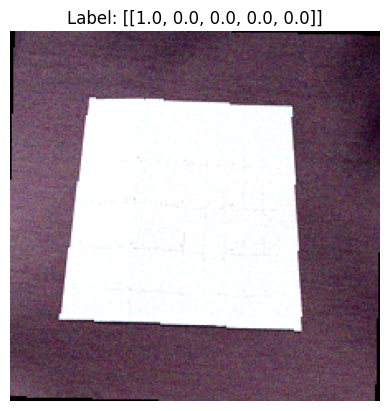

In [34]:
# Visualise an image from the dataloader and see whether it is sensible 
import time as time 

time_start = time.time()
dataiter = iter(train_dataloader)  # Get an iterator from the dataloader
image, label = next(dataiter)  # Get one batch
time_stop = time.time()

print(time_stop - time_start) 

# Convert the tensor to a NumPy array for visualization
image = image[0].permute(1, 2, 0).cpu().numpy()  # Convert (C, H, W) → (H, W, C)

# Unnormalize if needed (assuming mean=[0.5, 0.5, 0.5] and std=[0.5, 0.5, 0.5])
image = image * 0.5 + 0.5  # Convert from [-1,1] back to [0,1]

# Display the image
plt.figure()
plt.imshow(image)
plt.axis("off")
plt.title(f"Label: {label[0].tolist()}")
plt.show()

In [ ]:
# Define a model 
# Start with a pretrained ResNet that we are going to fine tune with the ECG data 

import torchvision.models as models
from torch import nn as nn

# Define the model
model = models.resnet18(weights='DEFAULT')

# Freeze all layers except the last fully connected layer
for param in model.parameters():
    param.requires_grad = False

# Replace the last fully connected layer to suit the multi-label classification problem
model.fc = nn.Linear(model.fc.in_features, 5)  # 5 output classes for multi-label classification

# Now only the last layer will have its parameters updated
for param in model.fc.parameters():
    param.requires_grad = True

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0, save_best_model=True, path='best_model.pth'):
        """
        Args:
            patience (int): Number of epochs to wait for improvement.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            save_best_model (bool): Whether to save the best model based on validation loss.
            path (str): Path to save the best model.
        """
        self.patience = patience
        self.delta = delta
        self.save_best_model = save_best_model
        self.path = path
        self.counter = 0
        self.best_loss = float('inf')  # Initialize to a large number (worst case)
        self.early_stop = False
        self.best_model_wts = None  # To store best model weights

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0

            # Save the best model
            if self.save_best_model:
                self.best_model_wts = model.state_dict()
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.early_stop = True
            print(f"Early stopping triggered after {self.patience} epochs with no improvement in validation loss.")
            # Load the best weights
            if self.save_best_model:
                model.load_state_dict(self.best_model_wts)
            return True
        
        return False

In [ ]:
from tqdm import tqdm

In [ ]:
import torch.nn as nn 
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR


# Set up the optimizer (only for the parameters of the last layer)
optimizer = optim.Adam(model.fc.parameters(), lr=1e-5)  # Start with a very low learning rate

# Define the loss function (use BCEWithLogitsLoss for multi-label classification)
criterion = nn.BCEWithLogitsLoss()

# Learning Rate Scheduler: OneCycleLR
# Warm-up and decay the learning rate during training
scheduler = OneCycleLR(optimizer, max_lr=1e-3, total_steps=len(train_dataloader) * 20)  # Assuming 20 epochs

# Early Stopping
early_stopping = EarlyStopping(patience=5, delta=0.001, save_best_model=True, path='best_model.pth')

In [ ]:
# work out device 
device = torch.device("mps" if torch.backends.mps.is_available() \
                      else ("cuda" if torch.cuda.is_available() 
                            else "cpu"))

print(device)

model = model.to(device)

In [ ]:
# Check model doesn't produce nonsense output 

image_path = '/kaggle/input/bhf-data-science-centre-ecg-challenge/train_1/train_encoded_relabelled/train_000000.png'
model.eval()
image = Image.open(image_path).convert('RGB')
image_tensor = train_transform(image).unsqueeze(0).to(device)  # Add batch dimension (1, C, H, W)
output = model(image_tensor)

print(type(output))
print(output.shape)
print(output)


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    # Wrap the training loop with tqdm
    for inputs, labels in tqdm(train_dataloader, desc=f"Epoch {epoch+1} - Training", unit="batch"):
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.squeeze(1) # need to squeeze out odd dimension in labels
        
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Compute the loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update the optimizer
        optimizer.step()

        # Update the learning rate scheduler
        scheduler.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}")

    # Validation loop with tqdm
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in tqdm(val_dataloader, desc=f"Epoch {epoch+1} - Validation", unit="batch"):
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.squeeze(1) # need to squeeze out odd dimension in labels 
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Validation Loss: {avg_val_loss:.4f}")

    # Call early stopping
    if early_stopping(avg_val_loss, model):
        print(f"Training stopped early at epoch {epoch+1}")
        break

    # Unfreeze layers after epoch 5
    if epoch == 4:  # After epoch 5 (0-indexed)
        print("Unfreezing all layers after epoch 5.")
        for param in model.parameters():
            param.requires_grad = True

        # Reinitialize the optimizer for all layers now
        optimizer = optim.Adam(model.parameters(), lr=1e-5)

        # Set up the scheduler again for the remaining epochs
        scheduler = OneCycleLR(optimizer, max_lr=1e-3, total_steps=len(train_dataloader) * (num_epochs - epoch))

In [ ]:
# Save the model's state_dict (recommended)
torch.save(model.state_dict(), 'model.pth')

In [ ]:
# Has output after training changed by much?

image_path = '/kaggle/input/bhf-data-science-centre-ecg-challenge/train_1/train_encoded_relabelled/train_000000.png'
model.eval()
image = Image.open(image_path).convert('RGB')
image_tensor = train_transform(image).unsqueeze(0)  # Add batch dimension (1, C, H, W)
output = model(image_tensor)

print(type(output))
print(output.shape)
print(output)